In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import graph_style as gs
import fig_helper as fh




gs.set_graph_style(1.0)


c:\Users\webbd\Documents\phd\Scratch\thesis\figures\make_figure\ch4\fig_helper.py:371: SyntaxWarning: invalid escape sequence '\m'
  p1_name = "$\\varepsilon_\mathrm{corr}$"
c:\Users\webbd\Documents\phd\Scratch\thesis\figures\make_figure\ch4\fig_helper.py:403: SyntaxWarning: invalid escape sequence '\m'
  p1_name = "$\\varepsilon_\mathrm{corr}$"


In [2]:

date = "2025-02-04"
rid = 16238

dict = fh.load_data(rid, date)

duration = np.array(dict["datasets"][f"ndscan.rid_{rid}.points.axis_0"])
pop = np.array(
    dict["datasets"][f"ndscan.rid_{rid}.points.channel_measurement_camera_readout_p"]
)
pop_err = np.array(
    dict["datasets"][
        f"ndscan.rid_{rid}.points.channel_measurement_camera_readout_p_err"
    ]
)
argsort = np.argsort(duration)
duration = duration[argsort]
pop = pop[argsort]
pop_err = pop_err[argsort]


<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
C:\Users\webbd\AppData\Local\Temp\ipykernel_24176\2235850480.py:43: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("729-nm Pulse Duration $t$ ($\mu$s)")


Omega = 2pi * 0.1433 +/- 0.0001 MHz
Initial Amp = 1.00 +/- 0.00
Decay rate = 0.0104 +/- 0.0006 1/$\mu$ s


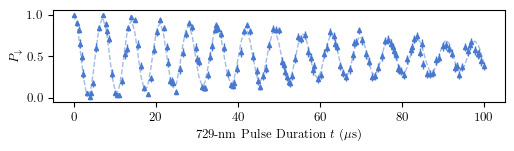

In [12]:
def decaying_sine(t, A, lambda_, W):
    A=1
    return 1 / 2 + A * np.exp(-lambda_ * t) * np.cos(W * t) / 2

p_fit, p_cov = curve_fit(
    decaying_sine,
    duration,
    pop,
    p0=[1, 1e6, 2 * np.pi * 1e5],
    bounds=([0, 0, 0], [1.1, 2 * np.pi * 2e5, 2 * np.pi * 1e7]),
)

p_err = np.sqrt(np.diag(p_cov))
print(
    f"Omega = 2pi * { p_fit[2] / (2 * np.pi*1e6):.4f} +/- {p_err[2] / (2 * np.pi*1e6):.4f} MHz"
)
print(f"Initial Amp = {p_fit[0]:.2f} +/- {p_err[0]:.2f}")
print(f"Decay rate = {p_fit[1]/1e6:.4f} +/- {p_err[1]/1e6:.4f} 1/$\\mu$ s")

fig = plt.figure()

fig_width = gs.get_fig_width()
fig_height = fig_width / gs.get_phi() / 3
fig.set_size_inches(fig_width, fig_height)

c = gs.get_color(0)
plt.errorbar(
    duration * 1e6, pop, yerr=pop_err, fmt="^", color=c, zorder=11, elinewidth=1.0
)
linrange = np.linspace(
    0,
    np.max(duration * 1e6),
    5000,
)
plt.plot(
    duration * 1e6,
    decaying_sine(duration, *p_fit),
    color=c,
    zorder=10,
    alpha=0.5,
    label="Fit: A=%.2f, lambda=%.2f, W=%.2f" % tuple(p_fit),
)
plt.xlabel("729-nm Pulse Duration $t$ ($\mu$s)")
plt.ylabel("$P_\\downarrow$")
plt.grid(None)
# plt.vlines(x=np.pi/(2*p_fit[2])*1e6, color="k", ls="--", lw=1.0, alpha=0.5, ymin=0, ymax=1)
# plt.show()
f_name = "..\\..\\pdf_figure\\ch4\\long_flop.pdf"
# plt.savefig(f_name, bbox_inches="tight")